# <span style="color:darkblue"> Introduction </span>

<font size = "5">

## <span style= "color:lightblue"> Jeremy Anderson Project 1
 
### <span style= "color:lightblue"> Data Information 
Websites Scraped: In this project, I scraped websites of each of the 12 members of the Southwestern Athletic Conference’s football rosters. Each team uses Sidearm to create their athletic website template and each team has a similar grid that houses their roster data from year to year. Standard information of player name, height, weight, position, hometown, and previous school is included in every year of each team’s roster tables (although the particular format varied, which require very complex code to capture). 

### <span style= "color:lightblue"> Date Collected:  10/21/2025

### <span style= "color:lightblue"> Number of Observations - 15,571

### <span style= "color:lightblue"> Data Collection Process 
For this project I set out to collect data on football rosters in the Southwestern Athletic Conference (SWAC). My larger research interest is to understand pipelines that colleges utilize to recruit talent from high schools. Schools in the major sporting division (Power 4) have roster that are readily available via college football APIs. For schools in smaller divisions—such as those in the SWAC—college football rosters can only be obtained in any systemic way via web scraping of the schools’ official athletic websites. I searched each SWAC school’s athletic website and fortunately they all use a common user interface to post their athletic rosters.
My web scraping depended on the beautiful soup package which searched for tables and column names on the roster websites. To gather all schools into one table, the code loops through years 2010-2025 (the earliest roster data I could find was 2010). Because each school records roster dating back to different years, I added code that automatically detected when certain schools no longer had roster data. For example. Jackson State doesn’t have any roster data before 2018. The code detected that there were no rosters for 2017, 2016, or 2015. After the 4th consecutive empty year, the code moved on to the next school without recording the empty rows. 

### <span style= "color:lightblue"> Description of the data
The data contains roster information for 12 different schools from between approximately 80-100 players from each season. The code produced 12 columns:

Season – the season represented on the roster 
Team – The school represented 
Number – The number the player wears
Names – The name of the player
Position – the position of the player
Height – height of the player
Weight – weight of the player
Class – The player’s classification
Hometown – the player’s hometown
High school – the high school the player attended
Previous School – If the player transferred from another college, that college shows up in this column
Source URL – The URL where the information comes from. 


Although the code produced 12 columns, for my future analysis will only include data on season, team, college, name, high school, previous school and hometown. Of these 7 variables, only high school and previous school have significant missing data. This makes sense, because college recruiting in athletics changed within the time frame that this data set coves. Before 2018, most recruiting involved college coaches recruiting directly from high schools, therefore only high schools were likely to be recorded in any team’s official roster website. Starting in 2018, the NCAA instituted the transfer portal, which allowed players at any college to transfer to any other college and play immediately, which ignited a shift in recruiting strategy in college athletics. In response to the change in recruiting, later college football rosters either added or switched “previous school” into their roster data. Previous School is inclusive of colleges that a player may have come from as well. For fan interest, documenting the high school a player comes from may be less interesting than what school an athlete transferred from. Different schools have different reasons to include high school and/or previous school in their rosters, and the variation of what’s included is reflected in the missingness data of high school and previous school. This isn’t uncommon or unexpected and functionally doesn’t change any of the core analysis I’ll be employing. 




# <span style="color:darkblue"> Block 1: Loading necessary Libraries </span>

<font size = "5">

Here, I'm importing all the libraries I'll use throughout the data collection process. 

- Requests is for HTTP requests
- BeautifulSoup is for HTML parsing
- Pandas for data manipulation
- Numpy for numerical operations
- Re for text matching
- Time for delays between requests

In [21]:
## IMPORT LIBRARIES
import re
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup
import numpy as np

# <span style="color:darkblue"> Block 2: Globals/Standardization </span>

<font size = "5">

First I standardized all the columns that the data will be scraped to. These columns mostly align with what's already in the online rosters, but certain team/year combinations treat hometown, high school, and previous school differently (the last bit of code handles this variation). This is set up for any of that to be parsed into one column (some teams choose to combine those columns on their websites). I created header aliases to account for any naming variation between schools. 

In [22]:
## Block 2 -- Globals: normalized schema, header aliases, merged patterns
# This block defines the standardized data structure and mapping rules for parsing football rosters

# ===== STANDARDIZED OUTPUT SCHEMA =====
# Final normalized columns - this is the target structure for all scraped data
# Every roster from every school/year will be transformed to match this exact format
NORMALIZED_COLS = [
    "season",          # Academic year (e.g., 2023 for 2023-24 season)
    "team",            # School name (e.g., "Jackson State", "Alabama A&M")
    "number",          # Jersey number (integer, e.g., 12, 99)
    "name",            # Player's full name (e.g., "John Smith")
    "position",        # Playing position (e.g., "QB", "RB", "WR")
    "height",          # Player height (e.g., "6-2", "5'11\"")
    "weight",          # Player weight (e.g., "185", "210 lbs")
    "class",           # Academic class (e.g., "Jr.", "Senior", "Freshman")
    "hometown",        # Player's hometown (e.g., "Atlanta, GA")
    "high_school",     # High school attended (e.g., "Central High School")
    "previous_school"  # Previous college/university (for transfer players)
]

# ===== HEADER MAPPING DICTIONARY =====
# Maps various website header formats to our standardized column names
# Keys = our standard field names, Values = sets of possible website headers (all lowercase)
HEADER_ALIASES = {
    # Jersey number variations
    "number": {"#", "no", "num", "number", "jersey"},
    
    # Player name variations
    "name": {"name", "student-athlete", "student athlete", "player", "full name"},
    
    # Position variations  
    "position": {"pos", "position"},
    
    # Height variations
    "height": {"ht", "height", "ht."},
    
    # Weight variations
    "weight": {"wt", "weight", "wt."},
    
    # Academic class/year variations
    "class": {"class", "yr", "year", "academic year", "eligibility", "elig yr", "cl.", "cl"},
    
    # Hometown variations
    "hometown": {"hometown", "home town", "city/state"},
    
    # High school variations
    "high_school": {"hs", "highschool", "high school", "hs name"},
    
    # Previous/transfer school variations
    "previous_school": {
        "previous school","prev school","previous","last school","previous college",
        "prev college","college","university","prior school"
    },
}

# ===== MERGED COLUMN PATTERNS =====
# Some websites combine multiple data fields into a single column
# This dictionary defines common merged patterns we need to split apart
MERGED_PATTERNS = {
    # Pattern: "Hometown / High School" combined in one column
    "hometown_high_school": [
        "hometown/high school","hometown / high school","home/hs","hometown/hs",
        "city/state/high school","hometown – high school","hometown- high school"
    ],
    
    # Pattern: "Hometown / Previous School" combined in one column  
    "hometown_previous_school": [
        "hometown/previous school","hometown / previous school","home/previous school",
        "hometown/last school","hometown / last school","city/state/previous school",
        "hometown/previous college","hometown / previous college"
    ],
}

# <span style="color:darkblue"> Block 3: Text Cleaning </span>

<font size = "5">

This block of code contains helper functions that clean messy data that may potentially come from scraping rosters with values within the columns. These commands ensure whitespace is normalized as when it's transferred into the data frame. 


In [23]:
# Block 3 -- Small Text Helpers
# This block contains utility functions for cleaning and processing text data from web scraping
# These functions handle the messy, inconsistent text formatting found on different websites

def text(el):
    """
    Safe string extractor for BeautifulSoup elements.
    
    Purpose: Extract clean text from HTML elements while handling edge cases
    - Safely handles None/empty elements without crashing
    - Normalizes whitespace (multiple spaces/tabs/newlines → single space)
    - Strips leading/trailing whitespace
    
    Args:
        el: BeautifulSoup element (could be None)
    
    Returns:
        Clean string with normalized whitespace
    
    Example:
        <td>  John   Smith  </td> → "John Smith"
    """
    return re.sub(r"\s+", " ", (el.get_text(" ", strip=True) if el else "")).strip()

def _canon_text(s: str) -> str:
    """
    Canonicalize text strings for consistent formatting.
    
    Purpose: Standardize text by normalizing whitespace
    - Handles None values safely (returns empty string)
    - Collapses multiple whitespace characters into single spaces
    - Removes leading/trailing whitespace
    
    Args:
        s: Input string (may be None)
    
    Returns:
        Cleaned string with normalized whitespace
    
    Example:
        "  Atlanta,    GA  " → "Atlanta, GA"
    """
    if s is None: return ""
    return re.sub(r"\s+", " ", s).strip()

def _canon_key(s: str) -> str:
    """
    Create canonical keys for header matching.
    
    Purpose: Convert messy header text into clean, comparable keys
    - Removes all non-word characters (punctuation, spaces, etc.)
    - Converts to lowercase for case-insensitive matching
    - Handles None values safely
    
    Args:
        s: Header text from website (may be None)
    
    Returns:
        Clean lowercase key with only letters/numbers
    
    Example:
        "Ht." → "ht"
        "Student-Athlete" → "studentathlete"
        "Home/Town" → "hometown"
    """
    return re.sub(r"[^\w]+", "", (s or "").lower())

def _split_pair(val: str):
    """
    Split merged data fields like 'Hometown / High School' into separate parts.
    
    Purpose: Handle websites that combine two data points in one column
    - Splits on common separators: / – — | -
    - Handles various spacing around separators
    - Returns tuple of (left_part, right_part)
    - Gracefully handles single values (no separator found)
    
    Args:
        val: Combined string like "Atlanta, GA / Central High School"
    
    Returns:
        Tuple: (left_part, right_part) or (original_value, None) if no split
    
    Example:
        "Atlanta, GA / Central High School" → ("Atlanta, GA", "Central High School")
        "Jacksonville State University" → ("Jacksonville State University", None)
        "Miami, FL – Previous College" → ("Miami, FL", "Previous College")
    """
    if not val: return (None, None)
    
    # Clean the input text first
    s = _canon_text(val)
    
    # Split on various separator patterns, then clean up each part
    parts = [p.strip(" /–—|-") for p in re.split(r"\s*[\/–—|-]\s*", s) if p.strip(" /–—|-")]
    
    if len(parts) >= 2:
        # Found separator: return left side and joined right sides
        return (_canon_text(parts[0]), _canon_text(" - ".join(parts[1:])))
    
    # No separator found: return original as left side, None as right
    return (_canon_text(s), None)

def _to_int(x):
    """
    Extract integer values from messy text (jersey numbers, etc.).
    
    Purpose: Convert text containing numbers to clean integers
    - Handles None values safely
    - Extracts first number found in string
    - Ignores non-numeric text around the number
    
    Args:
        x: Text that may contain a number (could be None, int, or string)
    
    Returns:
        Integer if number found, None otherwise
    
    Example:
        "#23" → 23
        "Jersey: 99" → 99
        "N/A" → None
        None → None
    """
    if x is None: return None
    m = re.search(r"\d+", str(x))  # Find first sequence of digits
    return int(m.group()) if m else None

# <span style="color:darkblue"> Block 3.5: Year Detection and Validation </span>

<font size = "5">

This block catches any variations in URL codes for schools who decided to put a year range for their rosters. In college football, most of the season is completed with a calendar year (August-December). Only a few teams ever play into January, spanning a new year. Therefore it's most common for schools to claim a roster as the "2022" roster, or "2022" roster. However some schools decided to buck against that convention and have 2022-23 as the year of the roster (which is techincally correct, just unnecssary). This code is meant to catch those variations. In previous attempts to scrape rosters, I ran into this issue with Jackson State, who has 2025, 2024, 2023, 2022, 2021-22, and 2020-21, 2019, and 2018 rosters on their official website. This disruptive naming convention lead to the code skipping 2021 an 2022 since the URLs didn't perfectly fit the globals, which looped from 2010-2025, with --(year) format. 

In [24]:
# Block 3.5 — Season/Year Detection & Validation (Redirect Guard)
# This block prevents data contamination from website redirects by validating the actual year
# Problem: Requesting /roster/2015 might redirect to /roster/2025, mixing old/new data

import re
from bs4 import BeautifulSoup

# ===== YEAR PATTERN REGEX =====
# Matches academic year patterns commonly found on college websites
# Examples: "2023", "2022-23", "2022-2023", "2022/23", "2022 / 2023"
YR_PAT = re.compile(r"\b(20\d{2})(?:\s*[-/]\s*(\d{2,4}))?\b")

def detect_year_from_dom(soup: BeautifulSoup):
    """
    Detect the actual season/year displayed on a webpage by examining DOM elements.
    
    Purpose: Determine what year the webpage actually shows (vs what we requested)
    - Checks common locations where websites display season information
    - Handles various year formats (2023, 2022-23, 2022-2023)
    - Returns tuple of (start_year, end_year) or (year, None)
    
    Args:
        soup: BeautifulSoup object of the webpage
    
    Returns:
        Tuple: (year1, year2) where year2 may be None
        - Single year: (2023, None)  
        - Academic year: (2022, 2023) for "2022-23"
        - No year found: (None, None)
    
    Example:
        Page shows "2022-23 Football Roster" → returns (2022, 2023)
        Page shows "2023 Season" → returns (2023, None)
    """
    
    # Probe common DOM locations where season information appears
    probes = []
    
    # Local helper function for safe text extraction
    def _t(el): 
        return re.sub(r"\s+", " ", el.get_text(" ", strip=True)) if el else ""
    
    # 1. Check main headers and title elements (most reliable)
    probes.append(_t(soup.select_one("h1, .sidearm-roster-header, .roster__header, .page-title")))
    
    # 2. Check page title tag
    probes.append(_t(soup.select_one("title")))
    
    # 3. Check dropdown selectors and season-specific elements
    probes.extend([_t(el) for el in soup.select("select[name*='season'] option[selected], .season, .roster-season")])
    
    # Combine all found text with separators for pattern matching
    joined = " | ".join([p for p in probes if p])

    # Search for year patterns in combined text, fallback to entire page
    m = YR_PAT.search(joined) or YR_PAT.search(_t(soup))
    if not m:
        return None, None

    # Parse the matched year pattern
    y1 = int(m.group(1))  # First year (always 4 digits)
    y2 = m.group(2)       # Second year (may be 2 or 4 digits, or None)
    
    if y2:
        # Handle 2-digit vs 4-digit second year
        # "2022-23" → y2="23" → convert to 2023
        # "2022-2023" → y2="2023" → keep as 2023
        y2 = int((str(y1//100) + y2) if len(y2) == 2 else y2)
        return y1, y2
    
    return y1, None

def url_mentions_year(final_url: str, y: int):
    """
    Check if a URL contains references to a specific year.
    
    Purpose: Verify if the final URL (after redirects) mentions the requested year
    - Handles various URL year formats: "2023", "2022-23", "2022-2023"
    - Used as fallback when DOM parsing fails
    
    Args:
        final_url: The actual URL after following redirects
        y: The year we're looking for
    
    Returns:
        Boolean: True if URL contains year references
    
    Example:
        URL: "...roster/2022-23/..." with y=2022 → True
        URL: "...roster/2025/..." with y=2015 → False
    """
    if not final_url: return False
    
    # Create different year format patterns to check
    ypair = f"{y}-{y+1}"           # e.g., "2022-2023"
    ypair2 = f"{y}-{str((y+1)%100).zfill(2)}"  # e.g., "2022-23"
    
    # Check if any pattern exists in the URL
    return (str(y) in final_url) or (ypair in final_url) or (ypair2 in final_url)

def is_year_match(requested_y: int, dom_y1, dom_y2, final_url: str):
    """
    Determine if a webpage actually contains data for the requested year.
    
    Purpose: Prevent data contamination from website redirects
    - Primary check: DOM-detected year matches requested year
    - Handles academic year spanning (e.g., 2022-23 season for 2022 request)
    - Fallback check: URL contains year tokens
    
    Critical Problem Solved:
        When you request /roster/2015, some sites redirect to /roster/2025
        This function catches that and rejects the 2025 data
    
    Args:
        requested_y: The year we originally requested (e.g., 2015)
        dom_y1: First year found in DOM (e.g., 2022 from "2022-23")  
        dom_y2: Second year found in DOM (e.g., 2023 from "2022-23")
        final_url: Actual URL after redirects
    
    Returns:
        Boolean: True if webpage matches requested year
    
    Examples:
        Requested 2022, DOM shows "2022-23" → True (academic year match)
        Requested 2015, DOM shows "2025" → False (redirect detected)
        Requested 2020, URL contains "2020-21" → True (URL fallback match)
    """
    
    # Primary validation: Check DOM-detected years
    if dom_y1:
        # Direct match: DOM year matches requested year
        if dom_y1 == requested_y: 
            return True
        
        # Academic year match: requested year spans to next year
        # e.g., requesting 2022 data, DOM shows "2022-15" format
        if dom_y2 and dom_y2 == requested_y + 1:
            return True
    
    # Fallback validation: Check URL tokens when DOM parsing unclear
    return url_mentions_year(final_url, requested_y)

# <span style="color:darkblue"> Block 4: Table Detection and Header Mapping </span>

<font size = "5">

In this block I set up Python to find tables with roster data in it on roster webpages. The globals created in block 2 are utilized here. Because there can be multiple tables on each page (roster, coaching staff, support staff), the code looks for the table that most likley contains roster data based on keywords that are likely to be found if the table has a roster (name, hometown, high school, etc.). 

In [ ]:
# Block 4 -- Table Detection + Header Mapping Intelligence
# This block finds the roster table on each webpage and maps messy headers to standardized fields
# Problem: Each school's website uses different table structures and column names

def _header_to_key(h: str) -> str | None:
    """
    Map a messy website header to a normalized field name or merged token.
    
    Purpose: Convert various header formats to standardized field names
    - Uses multiple strategies: merged patterns, heuristics, direct aliases
    - Priority order ensures most specific matches are found first
    - Returns None for unrecognized headers (ignored during parsing)
    
    Args:
        h: Header text from website table (e.g., "Ht.", "Student-Athlete", "Hometown/HS")
    
    Returns:
        Standardized field name or None if unrecognized
        - Standard fields: "name", "position", "height", etc.
        - Merged tokens: "hometown_high_school", "hometown_previous_school"
        - None: Unrecognized header (will be skipped)
    
    Examples:
        "Student-Athlete" → "name"
        "Pos" → "position"  
        "Hometown/High School" → "hometown_high_school"
        "Random Column" → None
    """
    # Clean and normalize the header text
    h_clean = _canon_text(h)
    hk = h_clean.lower()

    # STRATEGY 1: Check for merged column patterns first (highest priority)
    # These are specific patterns like "Hometown/High School" that need special handling
    for token, patterns in MERGED_PATTERNS.items():
        for p in patterns:
            if p in hk:
                return token
    
    # STRATEGY 2: Heuristic detection for merged patterns not in predefined list
    # Use keyword combination logic for edge cases
    if "hometown" in hk and "high" in hk and "school" in hk:
        return "hometown_high_school"
    if "hometown" in hk and any(w in hk for w in ["previous","last","college","university","prev"]):
        return "hometown_previous_school"

    # STRATEGY 3: Direct alias lookup for standard single-field headers
    # Convert header to canonical key and check against known aliases
    ck = _canon_key(h_clean)  # Remove punctuation, convert to lowercase
    for norm, aliases in HEADER_ALIASES.items():
        # Check if cleaned header matches any alias for this normalized field
        if ck in {_canon_key(a) for a in aliases}:
            return norm
    
    # STRATEGY 4: No match found - return None (header will be ignored)
    return None

def _find_roster_table(soup: BeautifulSoup):
    """
    Intelligently identify which table contains the roster data on a webpage.
    
    Purpose: Find the "most roster-like" table when multiple tables exist
    - Scans all tables and scores them based on roster-related keywords
    - Handles different header structures (<th> vs <td> in first row)
    - Returns the highest-scoring table and its headers
    
    Problem Solved:
        Many websites have multiple tables (navigation, stats, news, etc.)
        We need to automatically pick the one with player roster data
    
    Args:
        soup: BeautifulSoup object of the webpage
    
    Returns:
        Tuple: (best_table, headers_list) or None if no roster-like table found
        - best_table: BeautifulSoup table element with highest roster score
        - headers_list: List of header texts from that table
    
    Scoring Logic:
        Each table gets points for containing roster keywords like:
        "name", "position", "hometown", "height", "weight", etc.
    """
    # Find all table elements on the page
    candidate_tables = soup.find_all("table")
    best = None
    best_score = -1
    
    # Keywords that indicate a roster table (case-insensitive)
    keywords = {"name","position","hometown","high","previous","class","#","no","height","weight"}

    # Evaluate each table for "roster-likeness"
    for tbl in candidate_tables:
        # STEP 1: Try to extract headers from <th> elements
        ths = [th.get_text(" ", strip=True) for th in tbl.find_all("th")]
        
        # STEP 2: Fallback - check if first row uses <td> instead of <th>
        # Some websites use <td> for everything, even headers
        if not ths:
            first_tr = tbl.find("tr")
            if first_tr:
                ths = [td.get_text(" ", strip=True) for td in first_tr.find_all("td")]
        
        # STEP 3: Skip tables with no discernible headers
        if not ths:
            continue
        
        # STEP 4: Score this table based on roster keyword presence
        head_text = " ".join(ths).lower()  # Combine all headers into searchable text
        score = sum(1 for k in keywords if k in head_text)  # Count keyword matches
        
        # STEP 5: Update best table if this one scores higher
        if score > best_score:
            best_score = score
            best = (tbl, ths)  # Store both table element and header list
    
    return best  # Returns (table, headers) or None if no good match found

def _build_keymap(headers: list[str]) -> list[str | None]:
    """
    Create a mapping list that aligns website headers with normalized field names.
    
    Purpose: Build a "translation guide" for parsing table rows
    - Takes raw headers from website table
    - Maps each to standardized field name (or None if unrecognized)
    - Maintains positional alignment for row parsing
    
    Args:
        headers: List of header strings from website table
        Example: ["#", "Student-Athlete", "Pos", "Hometown/High School"]
    
    Returns:
        List of normalized keys aligned with headers
        Example: ["number", "name", "position", "hometown_high_school"]
        - Same length as input headers list
        - None values for unrecognized headers
        - Used during row parsing to know which column is which
    
    Why This Matters:
        When parsing table rows, we need to know:
        - Column 0 = "#" → maps to "number" field
        - Column 1 = "Student-Athlete" → maps to "name" field  
        - Column 2 = "Pos" → maps to "position" field
        - Column 3 = "Hometown/High School" → maps to "hometown_high_school" field
    """
    return [_header_to_key(h) for h in headers]

# <span style="color:darkblue"> Block 4.5 Duplicate Year Detection Functions </span>

<font size = "5">

This block provides a secondary implementation of year detection functions with slightly different logic patterns. It contains simplified versions of DOM year detection and URL year validation functions as backup methods.



In [26]:
# BLOCK 4.5 — season/year detection & validation
YR_PAT = re.compile(r"\b(20\d{2})(?:\s*[-/]\s*(\d{2,4}))?\b")

def detect_year_from_dom(soup):
    # Try common spots for the season text
    probes = []
    probes += [text(soup.select_one("h1, .sidearm-roster-header, .roster__header, .page-title"))]
    probes += [text(soup.select_one("title"))]
    probes += [text(el) for el in soup.select("select[name*='season'] option[selected], .season, .roster-season")]
    joined = " | ".join([p for p in probes if p])

    m = YR_PAT.search(joined)
    if not m:
        # also look for season text on the page anywhere (cheap)
        m = YR_PAT.search(text(soup))
    if not m:
        return None, None

    y1 = int(m.group(1))
    y2 = m.group(2)
    if y2:
        if len(y2) == 2:
            y2 = int(str(y1//100) + y2)
        else:
            y2 = int(y2)
        return y1, y2
    return y1, None

def url_has_year(final_url, intended_year):
    y = str(intended_year)
    ypair = f"{intended_year}-{intended_year+1}"
    ypair2 = f"{intended_year}-{str((intended_year+1)%100).zfill(2)}"
    return (y in final_url) or (ypair in final_url) or (ypair2 in final_url)

def is_year_match(intended_year, dom_y1, dom_y2, final_url):
    # Accept if DOM says intended_year or a range that starts with it
    if dom_y1:
        if dom_y1 == intended_year:
            return True
        if dom_y2 and dom_y1 == intended_year:
            return True
        # Sometimes DOM uses the *second* year label (e.g., 2014-15 shows "2015")
        if dom_y2 and dom_y2 == intended_year+1:
            return True
    # Fallback: URL tokens
    if final_url and url_has_year(final_url, intended_year):
        return True
    return False


# <span style="color:darkblue"> Block 5: Core Data Parser </span>

<font size = "5">

This is the main roster data extraction engine. The parse_swac_grid() function does the heavy lifting here. This function finds roster tables, maps headers to standard fields, extracts and cleans player data from each row, handles merged field splitting, converts data types, and returns a clean DataFrame with standardized columns and automatic deduplication

In [27]:
## Block 5 -- Core Parser: Grid-Only, Header-Driven, Transfer-Aware
# This is the main parsing engine that extracts player roster data from individual webpages
# Combines all previous helper functions to transform messy HTML tables into clean DataFrames

def parse_swac_grid(url: str, season: int, team: str) -> pd.DataFrame:
    """
    Parse a single school's roster webpage and return standardized player data.
    
    This is the main parsing function that orchestrates the entire extraction process:
    1. Fetches the webpage HTML
    2. Finds the roster table among all tables on the page
    3. Maps website headers to standardized field names
    4. Extracts and cleans player data from each row
    5. Handles merged fields (hometown/high school combinations)
    6. Returns clean DataFrame with standardized columns
    
    Args:
        url: Direct URL to the roster page
        season: Academic year (e.g., 2023 for 2023-24 season)
        team: School name (e.g., "Jackson State")
    
    Returns:
        DataFrame with standardized NORMALIZED_COLS structure
        - Empty DataFrame if no roster table found or parsing fails
        - Includes automatic deduplication of duplicate player records
    
    Key Features:
        - Automatic table detection among multiple page tables
        - Smart header mapping to handle different website formats  
        - Merged field splitting (e.g., "Atlanta, GA / Central High")
        - Player name link extraction (handles <a> tags in name cells)
        - Data type conversion and cleaning
    """
    
    # STEP 1: FETCH WEBPAGE CONTENT
    # Get raw HTML from the roster URL with reasonable timeout
    html = requests.get(url, timeout=30).text
    soup = BeautifulSoup(html, "html.parser")

    # STEP 2: FIND THE ROSTER TABLE
    # Use intelligent table detection to find roster among all page tables
    found = _find_roster_table(soup)
    if not found:
        # No roster table found - return empty DataFrame with correct structure
        return pd.DataFrame(columns=NORMALIZED_COLS)

    # STEP 3: EXTRACT TABLE STRUCTURE
    # Unpack the found table and its headers
    table, headers = found
    keymap = _build_keymap(headers)  # Map headers to standardized field names

    # STEP 4: LOCATE TABLE ROWS
    # Prefer <tbody> for data rows, fall back to entire table if no <tbody>
    body = table.find("tbody") or table
    trs = body.find_all("tr")  # Get all table rows

    # STEP 5: HANDLE HEADER ROW EDGE CASE
    # Some websites use <td> instead of <th> for headers in first row
    # If we detect this pattern, skip the first data row (it's actually headers)
    if trs and headers and all(el.name == "td" for el in (table.find("tr") or body).find_all(["th","td"])):
        trs = trs[1:]  # Skip first row if it contains headers in <td> elements

    # STEP 6: PROCESS EACH PLAYER ROW
    rows = []
    for tr in trs:
        # Extract all cells from this row
        cells = tr.find_all(["td","th"])
        if not cells:
            continue  # Skip rows with no data cells
        
        # STEP 6A: RAW DATA EXTRACTION
        # Extract text from each cell according to the keymap
        raw = {}
        for i, td in enumerate(cells[:len(keymap)]):  # Only process mapped columns
            k = keymap[i]  # Get standardized field name for this column
            if not k:  # Skip unmapped columns (None in keymap)
                continue
            
            # Extract cell text with basic cleaning
            text = td.get_text(" ", strip=True)
            
            # STEP 6B: SPECIAL HANDLING FOR DIFFERENT FIELD TYPES
            if k in {"hometown_high_school","hometown_previous_school"}:
                # Merged fields: store raw text for later splitting
                raw[k] = text
            else:
                # Regular fields: apply field-specific extraction rules
                if k == "name":
                    # Player names often wrapped in <a> tags - extract from link if present
                    a = td.find("a")
                    text = a.get_text(" ", strip=True) if a else text
                raw[k] = text

        # STEP 7: RESOLVE MERGED FIELD CONFLICTS
        # Handle cases where data might come from separate OR merged columns
        # Priority: separate columns override merged columns if both exist
        
        # Initialize with any separate column values
        hometown = raw.get("hometown")
        high_school = raw.get("high_school")
        previous_school = raw.get("previous_school")

        # STEP 7A: Process hometown/high school merged field
        if raw.get("hometown_high_school"):
            h, hs = _split_pair(raw["hometown_high_school"])  # Split merged field
            hometown = hometown or h        # Use separate column if available, else merged
            high_school = high_school or hs # Use separate column if available, else merged

        # STEP 7B: Process hometown/previous school merged field  
        if raw.get("hometown_previous_school"):
            h, prev = _split_pair(raw["hometown_previous_school"])  # Split merged field
            hometown = hometown or h                    # Use separate column if available, else merged
            previous_school = previous_school or prev   # Use separate column if available, else merged

        # STEP 8: BUILD STANDARDIZED PLAYER RECORD
        # Create final player record with all standardized fields
        rows.append({
            "season": season,                                    # Provided parameter
            "team": team,                                       # Provided parameter
            "number": _to_int(raw.get("number")),              # Convert to integer, handle text
            "name": _canon_text(raw.get("name")),              # Clean text formatting
            "position": _canon_text(raw.get("position")),      # Clean text formatting
            "height": _canon_text(raw.get("height")),          # Clean text formatting
            "weight": _canon_text(raw.get("weight")),          # Clean text formatting
            "class": _canon_text(raw.get("class")),            # Clean text formatting
            "hometown": _canon_text(hometown),                  # Clean resolved hometown
            "high_school": _canon_text(high_school),           # Clean resolved high school
            "previous_school": _canon_text(previous_school),   # Clean resolved previous school
        })

    # STEP 9: CREATE AND CLEAN DATAFRAME
    # Convert list of player records to DataFrame with standardized structure
    df = pd.DataFrame(rows, columns=NORMALIZED_COLS).replace({"": pd.NA})
    
    # STEP 10: DEDUPLICATION
    # Remove duplicate players based on key identifying fields
    # Keep first occurrence of each unique (team, season, name, number) combination
    if not df.empty:
        df = df.drop_duplicates(subset=["team","season","name","number"], keep="first")
    
    return df

# <span style="color:darkblue"> Block 6: Debug and Preview Tools </span>

<font size = "5">

This block of code creates debugging functions.

In [28]:
## Block 6 -- Quick Header Preview + Sanity Checks
# This block provides debugging and testing utilities for development and troubleshooting
# These functions help verify that the scraper is working correctly before running full extraction

def preview_headers(url: str):
    """
    Quick debugging tool to examine how headers are detected and mapped on a specific page.
    
    Purpose: Test header detection logic on individual URLs without full scraping
    - Fetches a single webpage
    - Shows raw headers found in the roster table
    - Shows how those headers map to standardized field names
    - Useful for debugging mapping issues or adding new schools
    
    Args:
        url: Direct URL to a roster page to analyze
    
    Outputs:
        Prints raw headers and their mapped standardized names
        
    Example Usage:
        preview_headers("https://gojsutigers.com/sports/football/roster/2023")
        
    Output Example:
        HEADERS: ['#', 'Student-Athlete', 'Pos', 'Ht.', 'Wt.', 'Cl.', 'Hometown/High School']
        KEYMAP : ['number', 'name', 'position', 'height', 'weight', 'class', 'hometown_high_school']
    """
    html = requests.get(url, timeout=30).text
    soup = BeautifulSoup(html, "html.parser")
    found = _find_roster_table(soup)
    if not found:
        print("No roster-like table found.")
        return
    _, headers = found
    keymap = _build_keymap(headers)
    print("HEADERS:", headers)
    print("KEYMAP :", keymap)

def peek_df(df: pd.DataFrame, n=5):
    """
    Quick data preview utility for examining scraped DataFrames.
    
    Purpose: Provide fast overview of scraped data quality and structure
    - Shows first n rows of data
    - Displays missing data percentages for each column
    - Useful for spot-checking scraping results during development
    
    Args:
        df: DataFrame to preview (typically from parse_swac_grid())
        n: Number of rows to display (default: 5)
        
    Outputs:
        Prints DataFrame sample and null percentage summary
        
    Example Usage:
        df = parse_swac_grid(url, 2023, "Jackson State")
        peek_df(df, 3)
        
    Output Example:
        Shows player data and "height: 15.2% null, weight: 8.1% null" etc.
    """
    if df.empty:
        print("⚠️ DataFrame is EMPTY")
        return
    print(df.head(n))
    print("\nNull % by column:")
    print((df.isna().mean()*100).round(1).astype(str) + "%")

# <span style="color:darkblue"> Block 7: URL Generation and Scraping Configuration </span>

<font size = "5">

In this code I created: the master list of SWAC schools and their URL templates, scraping configuration parameters (delays, thresholds, timeout settings), and sophisticated URL generation functions: build_year_slugs() creates multiple year format variations, url_variants_from_template() generates parameter variations, and try_parse_any() attempts data extraction from multiple URL candidates with validation.

In [29]:
## Block 7 -- Year Loop with Smart Slugs and URL Fallbacks
# This block handles the complexity of generating multiple URL variations for each school/year combination
# Problem: Schools use inconsistent URL patterns and may change formats over time

from urllib.parse import urlparse, urlunparse, parse_qsl, urlencode

# ===== SCHOOL CONFIGURATION =====
# Master list of SWAC schools and their roster URL templates
# Each template uses {year} placeholder that gets replaced with actual years/slugs
SCHOOLS = {
    "Jackson State": "https://gojsutigers.com/sports/football/roster/{year}?view=2",
    "Alabama State": "https://bamastatesports.com/sports/football/roster/{year}?view=2",
    "Alabama A&M": "https://aamusports.com/sports/football/roster/{year}?view=2",
    "Southern": "https://gojagsports.com/sports/football/roster/{year}?view=2",
    "Prairie View A&M": "https://pvpanthers.com/sports/football/roster/{year}?view=2",
    "Texas Southern": "https://tsusports.com/sports/football/roster/{year}?view=2",
    "UAPB": "https://uapblionsroar.com/sports/football/roster/{year}?view=2",
    "Alcorn State": "https://alcornsports.com/sports/football/roster/{year}?view=2",
    "Grambling": "https://gsutigers.com/sports/football/roster/{year}?view=2",
    "Mississippi Valley State": "https://mvsusports.com/sports/football/roster/{year}?view=2",
    "Florida A&M": "https://famuathletics.com/sports/football/roster/{year}?view=2",
    "Bethune-Cookman": "https://bcuathletics.com/sports/football/roster/{year}?view=2"
}

# ===== SCRAPING CONFIGURATION =====
YEARS = list(range(2010, 2026))        # Years to scrape (2010-2025)
HEADLESS = True                         # Run browser in background (not used in current version)
PAGE_LOAD_TIMEOUT = 20                  # Maximum seconds to wait for page load
POLITE_DELAY = 1.5                     # Seconds to wait between requests (be nice to servers)
EMPTY_ROW_THRESHOLD = 1                # Minimum rows needed to consider data valid
AUTO_STOP_CONSECUTIVE = 4              # Stop after this many consecutive failures

# ===== URL GENERATION HELPERS =====

def build_year_slugs(y: int):
    """
    Generate multiple year format variations for a given academic year.
    
    Purpose: Different schools format academic years differently in their URLs
    - Some use single year: "2022" 
    - Some use academic year: "2021-22" (spanning fall 2021 to spring 2022)
    - Some use forward-looking: "2022-23" 
    
    Args:
        y: Target academic year (e.g., 2022 for 2022-23 academic year)
    
    Returns:
        List of year slug variations to try
        
    Example:
        build_year_slugs(2022) → ["2022", "2021-22", "2022-23"]
        
    Strategy:
        Try multiple patterns to maximize success rate across different school URL formats
    """
    yy = f"{y}"                                      # Single year: "2022"
    left = f"{y-1}-{str(y % 100).zfill(2)}"        # Previous academic year: "2021-22"
    right = f"{y}-{str((y+1) % 100).zfill(2)}"     # Current academic year: "2022-23"
    
    # Remove duplicates while preserving order
    seen = set()
    out = [s for s in [yy, left, right] if not (s in seen or seen.add(s))]
    return out

def url_variants_from_template(template: str, slug: str):
    """
    Generate URL parameter variations from a template and year slug.
    
    Purpose: Schools sometimes change URL parameters or have multiple valid formats
    - Some URLs work with ?view=2, others without
    - This generates both versions to increase success rate
    
    Args:
        template: URL template with {year} placeholder
        slug: Year string to substitute (e.g., "2022", "2021-22")
    
    Returns:
        List of URL variations to try
        
    Example:
        Input: "https://school.com/roster/{year}?view=2", "2022"
        Output: ["https://school.com/roster/2022?view=2", 
                "https://school.com/roster/2022"]
    """
    # Start with basic template substitution
    base = template.format(year=slug)
    urls = [base]

    # Parse URL to manipulate query parameters
    parsed = urlparse(base)
    q = dict(parse_qsl(parsed.query))
    
    if "view" in q:
        # If template has view parameter, also try without it
        if q:
            q2 = dict(q); q2.pop("view", None)
            url_no_view = urlunparse(parsed._replace(query=urlencode(q2)))
            urls.append(url_no_view)
    else:
        # If template lacks view parameter, also try with view=2
        q2 = dict(q); q2["view"] = "2"
        url_with_view = urlunparse(parsed._replace(query=urlencode(q2)))
        urls.append(url_with_view)

    # Remove duplicates while preserving order
    uniq = []
    seen = set()
    for u in urls:
        if u not in seen:
            uniq.append(u); seen.add(u)
    return uniq

def try_parse_any(urls, season, team):
    """
    Attempt to parse roster data from a list of candidate URLs with validation.
    
    Purpose: Robustly handle URL variations and redirect detection
    - Tries multiple URLs until one succeeds
    - Validates that the found page actually contains the requested year's data
    - Prevents data contamination from website redirects
    
    Args:
        urls: List of candidate URLs to try
        season: Expected academic year for validation
        team: School name for the roster
    
    Returns:
        Tuple: (DataFrame, successful_URL) or (empty_DataFrame, last_tried_URL)
        
    Key Features:
        - Redirect Detection: Rejects pages that redirect to wrong years
        - Year Validation: Uses DOM analysis to verify correct season
        - Error Resilience: Continues trying URLs if individual requests fail
        - Data Quality: Only returns data if it meets minimum row threshold
    """
    last_url = None
    for u in urls:
        last_url = u
        try:
            # Make HTTP request with custom headers and redirects enabled
            resp = requests.get(u, headers={"User-Agent":"RosterScraper/1.0"}, timeout=(10,20), allow_redirects=True)
            if not (200 <= resp.status_code < 300) or not resp.text.strip():
                continue  # Skip failed requests or empty responses
                
            # CRITICAL: Detect the actual season displayed on the final page
            soup = BeautifulSoup(resp.text, "html.parser")
            dom_y1, dom_y2 = detect_year_from_dom(soup)
            final_url = resp.url or u

            # Validate that this page actually contains the requested year's data
            if not is_year_match(season, dom_y1, dom_y2, final_url):
                # Page redirected to different year - skip to prevent data contamination
                continue

            # Parse the validated page
            df = parse_swac_grid(final_url, season=season, team=team)
            if not df.empty and len(df) > EMPTY_ROW_THRESHOLD:
                # Success: return data with source URL for tracking
                df["source_url"] = final_url
                return df, final_url
                
        except requests.RequestException:
            # Network/parsing error - continue trying other URLs
            continue

    # All URLs failed - return empty DataFrame with proper structure
    df = pd.DataFrame(columns=NORMALIZED_COLS)
    return df, last_url

# <span style="color:darkblue"> Block 8: Main Execution Loop </span>

<font size = "5">

This loop creates a roster for each school and each year, and saves a csv file for each, in addition to a file per team that covers each that's found between 2010 and 2025. The code present previews of what data is being obtained in each loop so I can stop the code if I see any issues. The code also handles errors and has auto-stop mechanisms after no more years are found for a school's roster. 

In [31]:
all_chunks = []
school_chunks = []
empty_streak = 0

for school, template in SCHOOLS.items():
    print(f"\n🏫 Processing {school}...")
    
    # reset for this school
    school_chunks = []
    
    for y in YEARS:
        slugs = build_year_slugs(y)
        
        candidate_urls = []
        for s in slugs:
            candidate_urls.extend(url_variants_from_template(template, s))
        
        # remove dupes
        seen = set()
        used = []
        for u in candidate_urls:
            if u not in seen:
                used.append(u)
                seen.add(u)
        
        print(f"   📅 {y}: trying {len(used)} variants...")
        
        df, final_url = try_parse_any(used, y, school)
        if not df.empty and len(df) > EMPTY_ROW_THRESHOLD:
            empty_streak = 0
            df["source_url"] = final_url
            school_chunks.append(df)
            print(f"   ✅ SUCCESS: {len(df)} players")
        else:
            empty_streak += 1
            print(f"   ❌ FAILED")
        
        time.sleep(POLITE_DELAY)
        
        if empty_streak >= AUTO_STOP_CONSECUTIVE:
            print(f"   🛑 Auto-stop after {empty_streak} failures")
            break
    
    print(f"   📊 School Summary: {len(school_chunks)} successful years")
    
    # === Save this school's results immediately ===
    if school_chunks:
        school_df = pd.concat(school_chunks, ignore_index=True)
        
        # save combined-by-school
        safe_team = re.sub(r"[^A-Za-z0-9]+", "_", school)
        combined_path = os.path.join(OUTPUT_DIR, f"{safe_team}_ALL_Seasons_roster.csv")
        school_df.to_csv(combined_path, index=False, encoding="utf-8-sig")
        print(f"💾 Saved (school combined): {combined_path} ({school_df.shape[0]} rows)")

        # also save per-season files (newest→oldest order)
        for season in sorted(school_df["season"].dropna().unique(), reverse=True):
            subset = school_df[school_df["season"] == season]
            file_name = f"{safe_team}_{season}_roster.csv"
            subset.to_csv(os.path.join(OUTPUT_DIR, file_name), index=False, encoding="utf-8-sig")
            print(f"  └─ Saved: {file_name} ({subset.shape[0]} rows)")

        # append to global master
        all_chunks.append(school_df)
    else:
        print(f"ℹ️ No data saved for {school}.")

# Build global combined (can be empty)
combined = pd.concat(all_chunks, ignore_index=True) if all_chunks else pd.DataFrame(columns=NORMALIZED_COLS + ["source_url"])
print("\n=== Combined shape:", combined.shape, "===")

## Took 13 minutes 42 seconds to run


===== Jackson State =====

Jackson State — Season 2025
Trying: https://gojsutigers.com/sports/football/roster/2025?view=2 | https://gojsutigers.com/sports/football/roster/2025 | https://gojsutigers.com/sports/football/roster/2024-25?view=2 ...

Preview — Jackson State 2025 (OK)
   season           team  number                name position height weight  \
0    2025  Jackson State       0  Travis Terrell Jr.       RB    5-9    170   
1    2025  Jackson State       0   Jeremiah Williams       DL    6-2    314   
2    2025  Jackson State       1     Khamauri Rogers       DB    6-0    173   
3    2025  Jackson State       1       Shemar Savage       WR    6-3    216   
4    2025  Jackson State       2    Ja'Naylon Dupree       WR    5-8    162   

   class             hometown               high_school  \
0    So.         Atlanta, Ga.              Creekside HS   
1  R-Sr.     Lexington, Miss.  Holmes County Central HS   
2    Gr.       Madison, Miss.  Holmes County Central HS   
3    Gr. 

C:\Users\jland\AppData\Local\Temp\ipykernel_30584\995944091.py:145: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  school_df = pd.concat(school_chunks, ignore_index=True)


💾 Saved (school combined): C:\Users\jland\OneDrive\Emory Essentials\Research\College Football Output\SWAC Rosters2\Texas_Southern_ALL_Seasons_roster.csv (1334 rows)
  └─ Saved: Texas_Southern_2025_roster.csv (98 rows)
  └─ Saved: Texas_Southern_2024_roster.csv (102 rows)
  └─ Saved: Texas_Southern_2023_roster.csv (97 rows)
  └─ Saved: Texas_Southern_2022_roster.csv (93 rows)
  └─ Saved: Texas_Southern_2021_roster.csv (104 rows)
  └─ Saved: Texas_Southern_2020_roster.csv (11 rows)
  └─ Saved: Texas_Southern_2019_roster.csv (93 rows)
  └─ Saved: Texas_Southern_2018_roster.csv (90 rows)
  └─ Saved: Texas_Southern_2017_roster.csv (90 rows)
  └─ Saved: Texas_Southern_2016_roster.csv (84 rows)
  └─ Saved: Texas_Southern_2015_roster.csv (70 rows)
  └─ Saved: Texas_Southern_2014_roster.csv (80 rows)
  └─ Saved: Texas_Southern_2013_roster.csv (79 rows)
  └─ Saved: Texas_Southern_2012_roster.csv (80 rows)
  └─ Saved: Texas_Southern_2011_roster.csv (76 rows)
  └─ Saved: Texas_Southern_2010_roster

# <span style="color:darkblue"> Block 9: Master File Export </span>

<font size = "5"> This code combines every team's roster csv into a master csv file with all teams and years combined into one file. 

In [32]:
### Block 9 -- Save to CSV
# Save one master file after all schools are processed
if not combined.empty:
    master_path = os.path.join(OUTPUT_DIR, "SWAC_Rosters_Combined.csv")
    combined.to_csv(master_path, index=False, encoding="utf-8-sig")
    print(f"\n📦 Master file saved: {master_path} ({combined.shape[0]} rows)")
else:
    print("⚠️ No combined data to save.")


📦 Master file saved: C:\Users\jland\OneDrive\Emory Essentials\Research\College Football Output\SWAC Rosters2\SWAC_Rosters_Combined.csv (15571 rows)


# <span style="color:darkblue"> Block 10: Loading Data to Prepare for Data Analysis </span>

<font size = "5">

In [37]:
##  Starting Analysis

swac_fball = r"C:\Users\jland\OneDrive\Emory Essentials\Research\College Football Output\SWAC Rosters2\SWAC_Rosters_Combined.csv"

df = pd.read_csv(swac_fball)

df


'C:\\Users\\jland\\OneDrive\\Emory Essentials\\Research\\College Football Output\\SWAC Rosters2\\SWAC_Rosters_Combined.csv'

# <span style="color:darkblue"> Block 13: Basic Data Diagnostics </span>

<font size = "5">

The single command shows the rows and columns.

In [40]:
## Diagnostics and missingness

df.shape 

## The dataset has 12 columns, and 15,571 different rows. The dataset is unique on player/year


(15571, 12)

# <span style="color:darkblue"> Block 12: Comprehensive Missing Data Analysis </span>

<font size = "5">

This block creates missingess data analysis that graphs the missingness stats by variable, school, and year. analyze_missing_data() generates detailed statistics about missing values by column, school, and year, while create_missing_visualizations() creates comprehensive charts showing missing data patterns.

🔍 Running comprehensive missing data analysis...

HBCU Football Roster Missing Data Analysis

Dataset Shape: 15,571 rows × 12 columns

📊 MISSING DATA SUMMARY:
         Column  Missing_Count  Missing_Percentage Data_Type
    high_school           8366               53.73    object
previous_school           7722               49.59    object
         weight           2942               18.89   float64
       position            778                5.00    object
         height            297                1.91    object
         number            282                1.81   float64
           name             91                0.58    object
       hometown             26                0.17    object
          class              2                0.01    object
           team              0                0.00    object
         season              0                0.00     int64
     source_url              0                0.00    object

✅ COMPLETE COLUMNS (no missing data): 3
   ['te

C:\Users\jland\AppData\Local\Temp\ipykernel_30584\2868676382.py:117: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  season_missing = df.groupby('season').apply(lambda x: (x.isna().sum().sum() / (len(x) * x.shape[1])) * 100)
C:\Users\jland\AppData\Local\Temp\ipykernel_30584\2868676382.py:131: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_missing = df.groupby('team').apply(lambda x: (x.isna().sum().sum() / (len(x) 

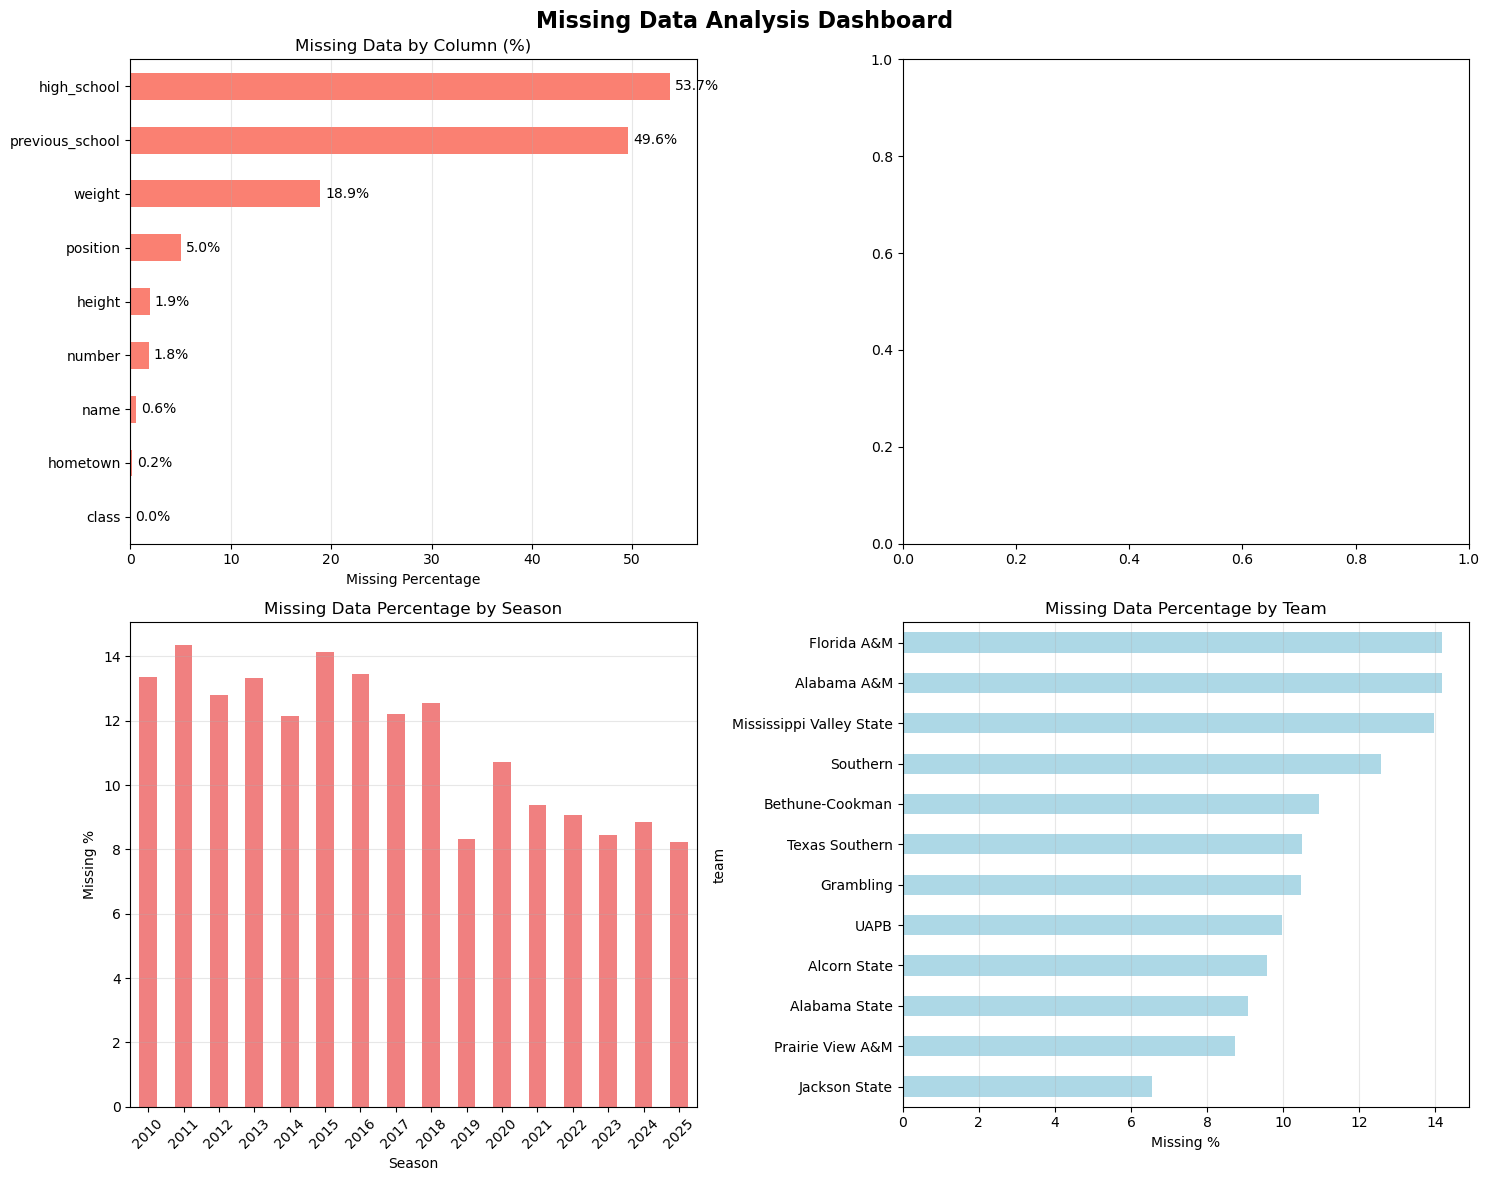


💡 ACTIONABLE INSIGHTS:
   • Overall missing rate: 11.0%
   • Consider removing or imputing: ['high_school', 'previous_school']
   • Most reliable fields: ['team', 'season', 'source_url']


In [46]:
# ===== MISSING DATA DIAGNOSTICS =====
# Import required libraries for data analysis and visualization
import numpy as np          # For numerical operations and NaN handling
import matplotlib.pyplot as plt  # For creating plots and charts
import seaborn as sns       # For enhanced statistical visualizations

def analyze_missing_data(df: pd.DataFrame, title: str = "Missing Data Analysis"):
    """
    Comprehensive missing data analysis for the roster DataFrame.
    
    This function provides detailed statistics about missing values including:
    - Basic dataset information (shape, size)
    - Missing count and percentage for each column
    - Identification of complete vs problematic columns
    - Missing data patterns by school and year
    - Overall completeness statistics
    
    Args:
        df: DataFrame to analyze
        title: Custom title for the analysis output
    
    Returns:
        missing_df: DataFrame with detailed missing data statistics
    """
    
    # Safety check - ensure DataFrame exists and has data
    if df.empty:
        print("DataFrame is empty - no missing data to analyze.")
        return
    
    # Print formatted header for the analysis
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    
    # 1. BASIC DATASET INFORMATION
    # Show overall size and structure of the dataset
    print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    
    # 2. DETAILED MISSING DATA CALCULATION
    # Create comprehensive missing data statistics for each column
    missing_info = []
    for col in df.columns:
        missing_count = df[col].isna().sum()  # Count NaN values
        missing_pct = (missing_count / len(df)) * 100  # Calculate percentage
        missing_info.append({
            'Column': col,
            'Missing_Count': missing_count,
            'Missing_Percentage': missing_pct,
            'Data_Type': str(df[col].dtype)  # Track data type for context
        })
    
    # Convert to DataFrame and sort by missing percentage (worst first)
    missing_df = pd.DataFrame(missing_info).sort_values('Missing_Percentage', ascending=False)
    
    # Display formatted table of missing data statistics
    print(f"\n📊 MISSING DATA SUMMARY:")
    print(missing_df.to_string(index=False, float_format='%.2f'))
    
    # 3. IDENTIFY COMPLETE COLUMNS (no missing values)
    # These columns are most reliable for analysis
    complete_cols = missing_df[missing_df['Missing_Count'] == 0]['Column'].tolist()
    if complete_cols:
        print(f"\n✅ COMPLETE COLUMNS (no missing data): {len(complete_cols)}")
        print(f"   {complete_cols}")
    
    # 4. FLAG HIGH MISSINGNESS COLUMNS (>50% missing)
    # These columns may need special handling or removal
    high_missing = missing_df[missing_df['Missing_Percentage'] > 50]
    if not high_missing.empty:
        print(f"\n⚠️  HIGH MISSINGNESS (>50%): {len(high_missing)} columns")
        for _, row in high_missing.iterrows():
            print(f"   • {row['Column']}: {row['Missing_Percentage']:.1f}%")
    
    # 5. ANALYZE MISSING PATTERNS BY SCHOOL AND YEAR
    # This helps identify if certain schools/years have more missing data
    if 'school' in df.columns and 'year' in df.columns:
        print(f"\n🏫 MISSING DATA BY SCHOOL:")
        # Calculate total missing values per school
        school_missing = df.groupby('school').apply(lambda x: x.isna().sum().sum()).sort_values(ascending=False)
        for school, total_missing in school_missing.head(5).items():
            total_possible = len(df[df['school'] == school]) * df.shape[1]
            pct = (total_missing / total_possible) * 100 if total_possible > 0 else 0
            print(f"   • {school}: {total_missing:,} missing values ({pct:.1f}%)")
        
        print(f"\n📅 MISSING DATA BY YEAR:")
        # Calculate total missing values per year
        year_missing = df.groupby('year').apply(lambda x: x.isna().sum().sum()).sort_values(ascending=False)
        for year, total_missing in year_missing.head(5).items():
            total_possible = len(df[df['year'] == year]) * df.shape[1]
            pct = (total_missing / total_possible) * 100 if total_possible > 0 else 0
            print(f"   • {year}: {total_missing:,} missing values ({pct:.1f}%)")
    
    # 6. CALCULATE COMPLETE ROWS
    # Rows with no missing values across all columns
    complete_rows = df.dropna().shape[0]
    complete_pct = (complete_rows / df.shape[0]) * 100
    print(f"\n📋 COMPLETE ROWS: {complete_rows:,} out of {df.shape[0]:,} ({complete_pct:.1f}%)")
    
    # 7. ANALYZE KEY FIELDS COMPLETENESS
    # Focus on the most important columns for football rosters
    key_fields = ['name', 'pos', 'number', 'school', 'year']
    existing_key_fields = [f for f in key_fields if f in df.columns]
    if existing_key_fields:
        print(f"\n🔑 KEY FIELD COMPLETENESS:")
        for field in existing_key_fields:
            complete_count = df[field].notna().sum()
            complete_pct = (complete_count / len(df)) * 100
            print(f"   • {field}: {complete_count:,}/{len(df):,} ({complete_pct:.1f}%) complete")
    
    return missing_df

def create_missing_visualizations(df: pd.DataFrame):
    """
    Create comprehensive visualizations for missing data patterns.
    
    This function generates multiple charts to help visualize:
    - Missing data percentage by column (horizontal bar chart)
    - Missing data trends by season (if season data exists)
    - Missing data patterns by team (if team data exists)
    
    Args:
        df: DataFrame to visualize missing data for
    """
    
    # Safety check for empty DataFrame
    if df.empty:
        print("DataFrame is empty - no visualizations to create.")
        return
    
    # Calculate missing percentages for all columns
    missing_pct = (df.isna().sum() / len(df)) * 100
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)  # Only show columns with missing data
    
    # If no missing data, no need for visualizations
    if missing_pct.empty:
        print("🎉 No missing data found - no visualizations needed!")
        return
    
    # Create a 2x2 subplot layout for comprehensive visualization dashboard
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Missing Data Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 1. MISSING PERCENTAGE BY COLUMN (Horizontal Bar Chart)
    # Shows which columns have the most missing data
    if len(missing_pct) > 0:
        ax1 = axes[0, 0]
        missing_pct.plot(kind='barh', ax=ax1, color='salmon')
        ax1.set_title('Missing Data by Column (%)')
        ax1.set_xlabel('Missing Percentage')
        ax1.grid(axis='x', alpha=0.3)  # Add light grid lines for easier reading
        
        # Add percentage labels to the end of each bar
        for i, v in enumerate(missing_pct.values):
            ax1.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    # 2. MISSING DATA BY SEASON (if season column exists)
    # Shows trends in data quality over different seasons
    ax3 = axes[1, 0]
    if 'season' in df.columns:
        # Calculate missing percentage for each season
        season_missing = df.groupby('season').apply(lambda x: (x.isna().sum().sum() / (len(x) * x.shape[1])) * 100)
        season_missing.plot(kind='bar', ax=ax3, color='lightcoral')
        ax3.set_title('Missing Data Percentage by Season')
        ax3.set_xlabel('Season')
        ax3.set_ylabel('Missing %')
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(axis='y', alpha=0.3)
    else:
        # Show placeholder if no season data
        ax3.text(0.5, 0.5, 'No season column found', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Missing Data by Season (N/A)')

    # 3. MISSING DATA BY TEAM (if team column exists)
    # Shows which teams have better/worse data quality
    ax4 = axes[1, 1]
    if 'team' in df.columns:
        # Calculate missing percentage for each team
        team_missing = df.groupby('team').apply(lambda x: (x.isna().sum().sum() / (len(x) * x.shape[1])) * 100)
        team_missing = team_missing.sort_values(ascending=True)  # Best to worst
        team_missing.plot(kind='barh', ax=ax4, color='lightblue')
        ax4.set_title('Missing Data Percentage by Team')
        ax4.set_xlabel('Missing %')
        ax4.grid(axis='x', alpha=0.3)
    else:
        # Show placeholder if no team data
        ax4.text(0.5, 0.5, 'No team column found', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Missing Data by Team (N/A)')
    
    # Adjust layout to prevent overlap and display the plots
    plt.tight_layout()
    plt.show()

# ===== MAIN EXECUTION BLOCK =====
# Run the analysis if df exists and contains data
if 'df' in locals() and not df.empty:
    print("🔍 Running comprehensive missing data analysis...")
    
    # STEP 1: Generate detailed text-based analysis
    missing_analysis = analyze_missing_data(df, "HBCU Football Roster Missing Data Analysis")
    
    # STEP 2: Create visual analysis dashboard
    print(f"\n📊 Creating missing data visualizations...")
    create_missing_visualizations(df)
    
    # STEP 3: Generate actionable summary and recommendations
    print(f"\n💡 ACTIONABLE INSIGHTS:")
    
    # Calculate overall missing data rate
    total_missing = df.isna().sum().sum()  # Total missing values across all cells
    total_possible = df.shape[0] * df.shape[1]  # Total possible values
    overall_missing_pct = (total_missing / total_possible) * 100
    
    print(f"   • Overall missing rate: {overall_missing_pct:.1f}%")
    
    # Identify most problematic columns (>25% missing)
    high_missing_cols = missing_analysis[missing_analysis['Missing_Percentage'] > 25]['Column'].tolist()
    if high_missing_cols:
        print(f"   • Consider removing or imputing: {high_missing_cols}")
    
    # Identify most reliable columns (0% missing)
    complete_cols = missing_analysis[missing_analysis['Missing_Percentage'] == 0]['Column'].tolist()
    if complete_cols:
        print(f"   • Most reliable fields: {complete_cols[:5]}")  # Show first 5 only
        
else:
    # Error message if no data is available
    print("⚠️ No df found. Please run the scraper first (cell 6) to generate data.")
